# Notebook 4: 04_Forecasting_Model

This notebook engineers dynamic time-series features (lags and rolling windows), trains the XGBoost forecasting engine, evaluates performance, and extracts SHAP values to make the AI's dispatch decisions fully explainable.

### Cell 1: Setup & Data Ingestion

In [ ]:
!pip install -q shap

import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import shap
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Loading Feature Data for ML Training...")

df = pd.read_parquet("data/processed/hotspot_features.parquet")
reporting_bias = pd.read_csv("data/processed/reporting_bias.csv")

print(f"✅ Successfully loaded {len(df)} records.")

Loading Feature Data for ML Training...
✅ Successfully loaded 184411 records.


### Cell 2: Advanced Feature Engineering (Time-Series Lags)
To predict a traffic jam, we need to know the momentum. We calculate 'Lag Features' (what happened in this exact spot 1 hour ago) and 'Rolling Features' (the buildup over the last 3 hours).

In [ ]:
print("Engineering Dynamic Time-Series Features...")

# 1. Aggregate down to the hourly Grid level
feature_table = df.groupby(["grid_lat", "grid_lon", "date", "hour", "dow"]).agg(
    total_violations=("device_id", "count"),
    avg_impact=("base_impact_score", "mean"),
    historical_risk_score=("historical_risk_score", "first")
).reset_index()

# Sort chronologically to ensure our lags look backwards in time correctly
feature_table = feature_table.sort_values(by=["grid_lat", "grid_lon", "date", "hour"])

# 2. Create Lag Features (Momentum)
# How many violations happened in this grid exactly 1 hour ago? (Shift by 1)
feature_table["lag_1h_violations"] = feature_table.groupby(["grid_lat", "grid_lon"])["total_violations"].shift(1).fillna(0)

# 3. Create Rolling Features (Buildup)
# What is the average violation count over the previous 3 hours?
feature_table["rolling_3h_avg"] = feature_table.groupby(["grid_lat", "grid_lon"])["total_violations"].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean().shift(1)
).fillna(0)

# 4. Define Target Variable (1 if >= 5 violations, 0 otherwise)
feature_table["is_future_hotspot"] = (feature_table["total_violations"] >= 5).astype(int)

print("✅ Lag and Rolling features successfully engineered.")
display(feature_table[["grid_lat", "grid_lon", "hour", "lag_1h_violations", "rolling_3h_avg", "total_violations", "is_future_hotspot"]].head())

Engineering Dynamic Time-Series Features...
✅ Lag and Rolling features successfully engineered.


,grid_lat,grid_lon,hour,lag_1h_violations,rolling_3h_avg,total_violations,is_future_hotspot
0,12.803,77.704,5,0.0,0.0,1,0
1,12.805,77.700,7,0.0,0.0,1,0
2,12.806,77.698,11,0.0,0.0,1,0
3,12.806,77.699,7,0.0,0.0,1,0
4,12.806,77.699,5,1.0,1.0,2,0


### Cell 3: Model Training (XGBoost)
We drop the target variable and train the model to map the engineered features to the target outcome.

In [ ]:
print("Preparing Training Matrix...")

# Select final feature subset
features = [
    "hour", "dow", "historical_risk_score",
    "lag_1h_violations", "rolling_3h_avg", "avg_impact"
]

X = feature_table[features]
y = feature_table["is_future_hotspot"]

# CRITICAL FIX: Chronological Split (shuffle=False) prevents data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("Training XGBoost Forecasting Engine...")
xgb_model = XGBClassifier(
    n_estimators=250,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train), # Adjusted to use training set ratio
    eval_metric="auc",
    random_state=42
)

xgb_model.fit(X_train, y_train)
print("✅ Model Trained Successfully!")

Preparing Training Matrix...
Training XGBoost Forecasting Engine...
✅ Model Trained Successfully!


### Cell 4: Model Evaluation

In [ ]:
print("--- MODEL EVALUATION REPORT ---")
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy:  {acc * 100:.2f}%")
print(f"ROC-AUC:   {auc:.4f} (Ability to separate threats from non-threats)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

--- MODEL EVALUATION REPORT ---
Accuracy:  80.32%
ROC-AUC:   0.8444 (Ability to separate threats from non-threats)

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.81      0.89     19728
           1       0.14      0.71      0.24       903

    accuracy                           0.80     20631
   macro avg       0.56      0.76      0.56     20631
weighted avg       0.95      0.80      0.86     20631



### Cell 5: SHAP Explainability
We calculate the SHapley Additive exPlanations to extract exactly how much each feature contributed to the model's decisions. This turns our 'Black Box' into a transparent logic engine.

Calculating SHAP Values for Explainability...


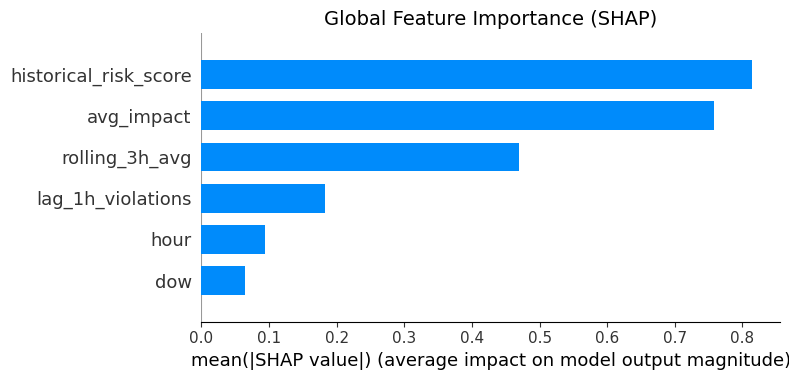

,Feature,Importance_Score
4,rolling_3h_avg,0.452643
5,avg_impact,0.281529
2,historical_risk_score,0.118167
3,lag_1h_violations,0.081415
0,hour,0.036922
1,dow,0.029323


In [ ]:
print("Calculating SHAP Values for Explainability...")

# Initialize SHAP TreeExplainer
explainer = shap.TreeExplainer(xgb_model)
# For performance in Colab, we explain a representative sample of the test set
sample_X_test = X_test.sample(n=min(5000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(sample_X_test)

# Generate the Global Feature Importance Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, sample_X_test, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP)", fontsize=14)
plt.tight_layout()
plt.show()

# Extract raw importance scores to save for the Streamlit dashboard
feature_importances = pd.DataFrame({
    'Feature': features,
    'Importance_Score': xgb_model.feature_importances_
}).sort_values(by='Importance_Score', ascending=False)

display(feature_importances)

### Cell 6: Exporting Artifacts

In [ ]:
print("Exporting Model and AI Artifacts...")

# 1. Save the trained XGBoost model
MODEL_PATH = "models/forecast_model.pkl"
joblib.dump(xgb_model, MODEL_PATH)

# 2. Save the SHAP Feature Importances
IMPORTANCE_PATH = "data/processed/feature_importance.csv"
feature_importances.to_csv(IMPORTANCE_PATH, index=False)

print(f"🚀 SUCCESS: Artifacts saved to:")
print(f" - {MODEL_PATH}")
print(f" - {IMPORTANCE_PATH}")
print("\nThe ML Architecture is complete and ready for Streamlit deployment.")

Exporting Model and AI Artifacts...
🚀 SUCCESS: Artifacts saved to:
 - models/forecast_model.pkl
 - data/processed/feature_importance.csv

The ML Architecture is complete and ready for Streamlit deployment.


In [ ]:
!pip install -q streamlit-folium

In [ ]:
# @title
!pip install streamlit pandas numpy hdbscan folium xgboost joblib scikit-learn shap pyngrok google-generativeai